In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 6** - Cake Recipe Optimisation (5D)

- Optimising a cake recipe using a black-box function with five ingredient inputs
    - E.g., example flour, sugar, eggs, butter and milk. 
    
- Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. 

- The total score is negative by design.

- **Goal** - bring the score as close to zero as possible.

**Input** - 5D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise (target: 0.0)  
**All-time best:** -0.089 at [0.555, 0.363, 0.637, 0.758, 0.126] (Week 12)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy')

# New data for Week 12 (Function 6)
X_w12_new_point = np.array([0.555002, 0.363159, 0.636987, 0.758428, 0.126452], dtype=np.float64)
Y_w12_new_point = np.array([-0.08871514584140812], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 6:', X_unique)
print('Updated Outputs (Y) - Function 6:', Y_updated)

Updated Inputs (X) - Function 6: [[2.17353077e-02 4.28084240e-01 8.35939437e-01 4.89488659e-01
  5.11081735e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [1.26678917e-01 2.91470301e-01 6.45284767e-02 6.80514603e-01
  8.92819191e-01]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [1.64117000e-01 2.15391000e-01 4.79099000e-01 7.26337000e-01
  6.00000000e-02]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [2.58905574e-01 7.93677708e-01 6.42113905e-01 1.96673464e-01
  5.93103177e-01]
 [4.32165933e-01 7.15617813e-01 3.41819103e-01 7.04999881e-01
  6.14961845e-01]
 [4.39344264e-01 6.98923833e-01 4.26820222e-01 1.09476085e-01
  8.77888468e-01]
 [4.41233000e-01 9.98122000e-01 1.24500000e-03 5.56711000e-01
  3.21098000e-01]
 [4.61344000e-01 3.23423000e-01 8.03851000e-01 9.69268000e-01
  2.51090000e-02]
 [4.87084000e-01 1.49390000e-02 9.99330000e-01 9.73696000e-01
  9.98860000e-02]
 [4.978

## **Output Analysis**

- **W11 Output:** -0.192 at [0.539, 0.388, 0.648, 0.761, 0.131]
- **W12 Output:** -0.089 at [0.555, 0.363, 0.637, 0.758, 0.126] (New all-time best)

- **Comparison:** This is the new all-time best, surpassing the w5 record of -0.128.
    - The improvement from -0.192 to -0.089 is the largest single-week gain for this function. 
    
    - The w12 profile [0.555, 0.363, 0.637, 0.758, 0.126] closely mirrors the w5 best [0.593, 0.387, 0.658, 0.780, 0.074] with minor differences in x5 (0.126 vs 0.074).

- **Real-World Implication:** A score of -0.089 represents a recipe that is very nearly optimal across all five judging criteria simultaneously. 
    - The taster is only penalising this recipe mildly as the ingredient proportions are well-balanced. 
    - The slightly higher x5 (more milk) versus the w5 best may be contributing positively to consistency.

- **Model Clues:** w13 must exploit this new peak. The w12 result is the new anchor. 
    - Centre on [0.555, 0.363, 0.637, 0.758, 0.126] with a tight grid. Retain all floor constraints.

## **Bayesian Optimisation** - Gaussian Process

- The Matérn (ν=2.5) + WhiteKernel GP is retained. 
    - For a recipe evaluation surface where ingredient proportions interact multiplicatively as too much of one ingredient changes the texture, moisture, and flavour simultaneously meaning the smooth ν=2.5 kernel correctly models a landscape without sharp discontinuities. 
    
- The WhiteKernel accounts for the inherent subjectivity in expert taster evaluation: the same recipe may receive slightly different scores across evaluations, and the WhiteKernel prevents the GP from over-indexing on this noise.

- The w12 breakthrough to -0.089 is the new all-time best and completely reframes the search. 
    - The previous best of -0.128 (w5) held for seven weeks; the new best represents a meaningful improvement in recipe quality. 
    
- The w12 profile [0.555, 0.363, 0.637, 0.758, 0.126] now serves as the primary anchor. 
    - The three floor constraints (x1≥0.45, x2≥0.30, x5≥0.06) are retained, they were empirically derived from twelve weeks of data and protected the search from the low-ingredient regions that caused the w10 catastrophe (-0.684). 
    
    - These constraints effectively reduce the 5D search space to a 5D subspace, allowing the GP to concentrate its model capacity on the region where recipes are actually competitive.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [-1.35668211 -2.57116963 -1.74688209 -1.23378638 -0.68442135 -1.20995524
 -1.70255784 -1.29424696 -2.0184254  -1.77750875 -0.51170708 -0.94759224
 -0.25085626 -0.16189869 -0.43136136 -1.14478485 -0.19203381 -0.08871515
 -0.12781661 -0.53162631 -0.82923655 -1.62283895 -0.60482914 -0.71426495
 -1.67219994 -1.30911635 -1.53605771 -0.93575656 -1.24704893 -2.15576776
 -1.69434344 -1.91267714]
Transformed Y: [-0.38638103 -2.05359226 -0.94676923 -0.20388776  0.65525847 -0.16813332
 -0.8844544  -0.29405761 -1.32179083 -0.98963968  0.94313934  0.23404795
  1.39879462  1.56095122  1.08060607 -0.06972279  1.50559018  1.69734173
  1.62411782  0.90942231  0.42107705 -0.77155208  0.78669292  0.60648939
 -0.84158666 -0.316117   -0.64739669  0.25258473 -0.22373321 -1.50735151
 -0.87287024 -1.17707748]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- EI with ξ=0.005 and a tighter std=0.015 is the w13 strategy. 
    - The ξ value is deliberately set between the ultra-greedy ξ=0.0003 used for F3 and the moderate ξ=0.01 used previously. 

    - At -0.089, we are close enough to zero to warrant aggressive exploitation, but the noisy expert-taster evaluation means a very low ξ risks chasing evaluation variance rather than genuine improvement. 
    
    - ξ=0.005 asks EI to find configurations with a meaningful expected improvement over -0.089 while not requiring the high certainty that ξ=0.0003 would demand. 
    
- The std is tightened from 0.02 to 0.015 because the new peak has been confirmed with a single reading as the GP's uncertainty around [0.555, 0.363, 0.637, 0.758, 0.126] is still relatively high, and a tighter focused grid ensures the w13 query lands in the direct neighbourhood of the new best. 

- The 90/10 split retains the small uniform component as a safeguard against premature convergence to a local optimum.

In [4]:
def expected_improvement(X, model, y_max, xi=0.005):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.555002, 0.363159, 0.636987, 0.758428, 0.126452])

x_focused = np.random.normal(loc=w_best, scale=0.015, size=(9000, 5))
x_uniform = np.random.uniform(0, 1, size=(1000, 5))
x_grid = np.vstack([x_focused, x_uniform])
# Empirical floor constraints from 12 weeks of data
x_grid[:, 0] = np.maximum(x_grid[:, 0], 0.45)  # x1 floor
x_grid[:, 1] = np.maximum(x_grid[:, 1], 0.30)  # x2 floor
x_grid[:, 4] = np.maximum(x_grid[:, 4], 0.06)  # x5 floor
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.005)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Week 13 Query Recommendation (Function 6): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}')

Best coordinates: [0.555002 0.363159 0.636987 0.758428 0.126452]
Week 13 Query Recommendation (Function 6): 0.524603-0.360079-0.606922-0.780207-0.159219


## **Visualisation**

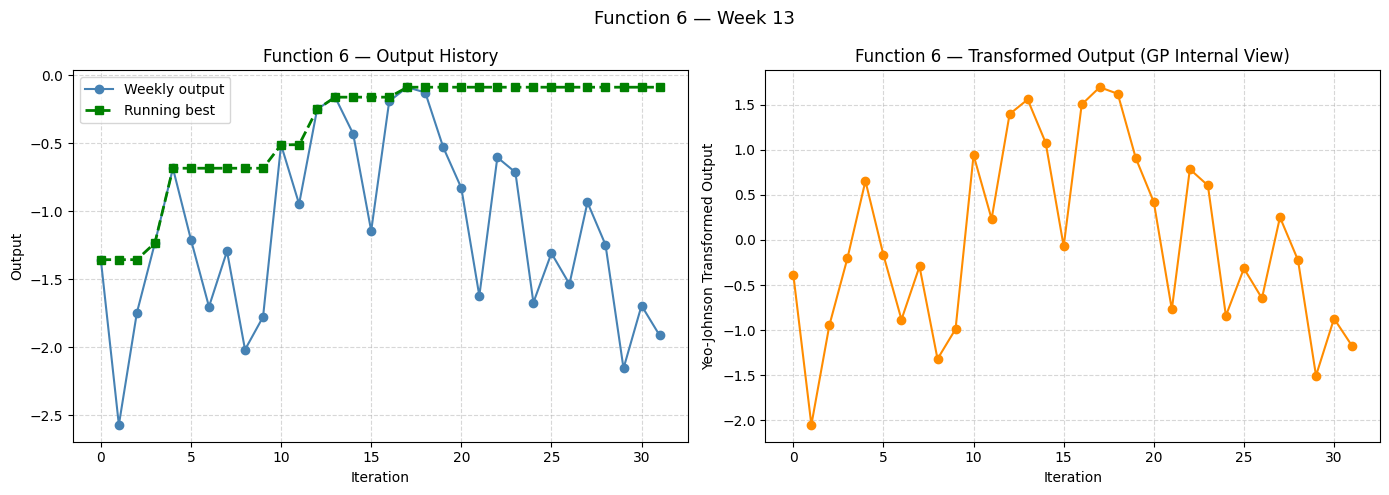

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 6 — Output History')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 6 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 6 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()